In [13]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import importlib
from utils import user_utils
importlib.reload(user_utils)

from matplotlib import rc
rc('font', family='Malgun Gothic')  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu
import utils.modeling      as um

In [15]:
# data loading
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


### 구현 단계
1. IQR 기반 이상치 판별
    - Q1 (25% 분위수), Q3 (75% 분위수) 계산
    - IQR = Q3 - Q1
    - 이상치 범위: x<Q1-1.5\cdot IQR\quad \mathrm{or}\quad x>Q3+1.5\cdot IQR

2. 각 피처별 이상치 개수 계산
    - 이상치 개수가 10,000건 이상인 피처만 추출

3. 그 피처들의 이상치 행 삭제
    - 여러 피처에서 이상치가 겹칠 수 있으므로, union 방식으로 행 제거

In [16]:
# 전처리

# 1. 이상치 개수 계산 함수
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

# 2. 피처별 이상치 개수 확인
outlier_counts = {}
for col in df.columns:
    if df[col].dtype != 'object':  # 수치형만
        outlier_counts[col] = count_outliers(df[col])

# 3. 이상치가 10,000건 이상인 피처 추출
selected_features = [col for col, cnt in outlier_counts.items() if cnt >= 10000]
print("이상치가 많은 피처들:", selected_features)

# 4. 해당 피처들의 이상치 행 삭제
mask = pd.Series([False] * len(df))
for col in selected_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask |= (df[col] < lower_bound) | (df[col] > upper_bound)

df_cleaned = df[~mask]
print("삭제 후 데이터 크기:", df_cleaned.shape)

이상치가 많은 피처들: ['V2', 'V4', 'V5', 'V6', 'V8', 'V12', 'V14', 'V19', 'V20', 'V21', 'V23', 'V27', 'V28', 'Amount']
삭제 후 데이터 크기: (162440, 31)


In [17]:
# Amount 피처 log1p + StandardScaled

from sklearn.preprocessing import StandardScaler


# Amount 로그 변환 + StandardScaler 적용
df['Amount_log'] = np.log1p(df['Amount'])   # log(Amount+1)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount_log'].values.reshape(-1, 1))

# 원본 Amount, Amount_log 제거
df = df.drop(['Amount', 'Amount_log'], axis=1)

In [18]:
# 특성과 타겟 분리 (Time 컬럼 제거)
X_features, y_target = pp.split_features_target(df, cols='Time')

# 학습/테스트 분할
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

In [19]:
# 각 모델 적용

# baseline 성능 확인
lr_best_params = {
    "random_state": 23,
    'C': 0.029,
    'max_iter': 1000,
    'penalty': 'l2',
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    "n_jobs": -1
}

# GradientBoostingClassifier 기본 파라미터
gb_basic_params = {
    'n_estimators': 100,      # 트리 개수 (더 많을수록 성능↑, 시간↑)
    'learning_rate': 0.1,     # 학습률 (0.01~0.3, 작을수록 안정적)
    'max_depth': 3,           # 개별 트리 깊이 (3~5 권장, 과적합 방지)
    'random_state': 23
}

# DecisionTreeClassifier 기본 파라미터
dt_basic_params = {
    'criterion': 'gini',      # 분할 기준 ('gini' 또는 'entropy')
    'max_depth': None,        # 트리 최대 깊이 (None=제한없음, 과적합 위험)
    'random_state': 23
}

# MLPClassifier 기본 파라미터
mlp_basic_params = {
    'hidden_layer_sizes': (64, 32),  # 은닉층 구조 (64개 노드 → 32개 노드)
    'activation': 'relu',             # 활성화 함수 (relu, tanh, logistic)
    'solver': 'adam',                 # 최적화 알고리즘 (adam, sgd, lbfgs)
    'alpha': 1e-4,                    # L2 정규화 파라미터 (과적합 방지)
    'batch_size': 256,                # 배치 크기 (메모리 허용 범위 내 크게)
    'learning_rate': 'adaptive',      # 학습률 스케줄 (adaptive, constant, invscaling)
    'max_iter': 50,                   # 최대 반복 횟수 (early stopping 권장)
    'random_state': 23
}

# LightGBM 기본 파라미터
lgb_basic_params = {
    'random_state': 23,
    'n_estimators': 400,       # 트리 개수 (기본 100, 많을수록 성능↑, 시간↑)
    'num_leaves': 36,          # 리프 노드 개수 (기본 31, 복잡도 조절)
    'learning_rate': 0.03,     # 학습률 (0.01~0.3 권장)
    'subsample': 0.9, 
    'colsample_bytree': 0.75,       # 부스팅 방식 (gbdt, dart, goss)
    'reg_alpha' : 0.6,
    'reg_lambda' : 0.2,
    'class_weight': {0:1, 1:10},    # 불균형 데이터 처리
    'n_jobs': -1                    # 병렬 처리
}

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

# 딕셔너리 저장소 생성

results_dict = {}


# 1. Logistic Regression
model_name = 'LogReg_DelOutlier_Amount_Timedrop__2025_11_27'
lr_clf = LogisticRegression(**lr_best_params)
results_dict['origin'] = uu.get_model_train_eval(lr_clf, model_name, X_train, X_test, y_train, y_test)

# 2. Gradient Boosting
model_name = 'GradientBoosting_DelOutlier_Amount_Timedrop__2025_11_27'
gb_clf = GradientBoostingClassifier(**gb_basic_params)
results_dict['gb'] = uu.get_model_train_eval(gb_clf, model_name, X_train, X_test, y_train, y_test)

# 3. Decision Tree
model_name = 'DecisionTree_DelOutlier_Amount_Timedrop__2025_11_27'
dt_clf = DecisionTreeClassifier(**dt_basic_params)
results_dict['dt'] = uu.get_model_train_eval(dt_clf, model_name, X_train, X_test, y_train, y_test)

# 4. MLP (Multi-Layer Perceptron)
model_name = 'MLP_DelOutlier_Amount_Timedrop__2025_11_27'
mlp_clf = MLPClassifier(**mlp_basic_params)
results_dict['mlp'] = uu.get_model_train_eval(mlp_clf, model_name, X_train, X_test, y_train, y_test)

# 5. LightGBM
model_name = 'LightGBM_DelOutlier_Amount_Timedrop__2025_11_27'
lgb_clf = LGBMClassifier(**lgb_basic_params)
results_dict['lgbm'] = uu.get_model_train_eval(lgb_clf, model_name, X_train, X_test, y_train, y_test)

# result_modles = '''
# ✓ 모델 저장 완료: ../models\LogReg_DelOutlier_Amount_Timedrop__2025_11_27.pkl
#   파일 크기: 0.00 MB
# folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
# AUC: 0.9590, 정확도: 0.9753, 정밀도: 0.0581, 재현율: 0.8776, F1: 0.1089
# 오차행렬:
# [[55469  1395]
#  [   12    86]]
# ✓ 모델 저장 완료: ../models\GradientBoosting_DelOutlier_Amount_Timedrop__2025_11_27.pkl
#   파일 크기: 0.13 MB
# folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
# AUC: 0.2959, 정확도: 0.9985, 정밀도: 0.7308, 재현율: 0.1939, F1: 0.3065
# 오차행렬:
# [[56857     7]
#  [   79    19]]
# ✓ 모델 저장 완료: ../models\DecisionTree_DelOutlier_Amount_Timedrop__2025_11_27.pkl
#   파일 크기: 0.03 MB
# folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
# AUC: 0.8927, 정확도: 0.9993, 정밀도: 0.7857, 재현율: 0.7857, F1: 0.7857
# 오차행렬:
# [[56843    21]
#  [   21    77]]
# ✓ 모델 저장 완료: ../models\MLP_DelOutlier_Amount_Timedrop__2025_11_27.pkl
#   파일 크기: 0.13 MB
# folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
# AUC: 0.9638, 정확도: 0.9996, 정밀도: 0.9205, 재현율: 0.8265, F1: 0.8710
# 오차행렬:
# [[56857     7]
#  [   17    81]]
# ✓ 모델 저장 완료: ../models\LightGBM_DelOutlier_Amount_Timedrop__2025_11_27.pkl
#   파일 크기: 1.47 MB
# folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
# AUC: 0.9675, 정확도: 0.9997, 정밀도: 0.9647, 재현율: 0.8367, F1: 0.8962
# 오차행렬:
# [[56861     3]
#  [   16    82]]
# '''

✓ 모델 저장 완료: ../models\LogReg_DelOutlier_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9590, 정확도: 0.9753, 정밀도: 0.0581, 재현율: 0.8776, F1: 0.1089
오차행렬:
[[55469  1395]
 [   12    86]]
실행 시간: 3.53132963180542
✓ 모델 저장 완료: ../models\GradientBoosting_DelOutlier_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.2959, 정확도: 0.9985, 정밀도: 0.7308, 재현율: 0.1939, F1: 0.3065
오차행렬:
[[56857     7]
 [   79    19]]
실행 시간: 299.48852133750916
✓ 모델 저장 완료: ../models\DecisionTree_DelOutlier_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.03 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.8927, 정확도: 0.9993, 정밀도: 0.7857, 재현율: 0.7857, F1: 0.7857
오차행렬:
[[56843    21]
 [   21    77]]
실행 시간: 20.06201171875
✓ 모델 저장 완료: ../models\MLP_DelOutlier_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\Cre

In [25]:
results_dict

{'origin': {'AUC': 0.959, '정밀도': 0.0581, '재현율': 0.8776, 'F1': 0.1089},
 'gb': {'AUC': 0.2959, '정밀도': 0.7308, '재현율': 0.1939, 'F1': 0.3065},
 'dt': {'AUC': 0.8927, '정밀도': 0.7857, '재현율': 0.7857, 'F1': 0.7857},
 'mlp': {'AUC': 0.9638, '정밀도': 0.9205, '재현율': 0.8265, 'F1': 0.871},
 'lgbm': {'AUC': 0.9675, '정밀도': 0.9647, '재현율': 0.8367, 'F1': 0.8962}}

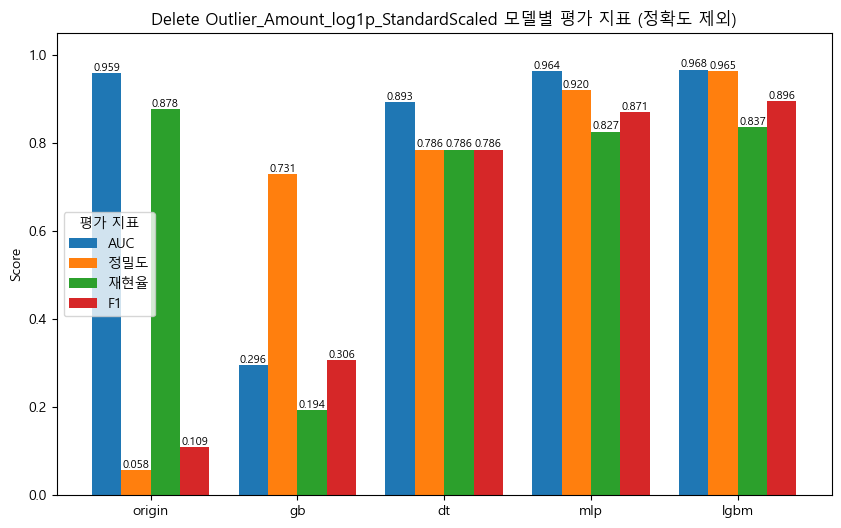

In [28]:
um.plot_sampling_metrics(results_dict,title='Delete Outlier_Amount_log1p_StandardScaled 모델별 평가 지표')